# Day 8: California Housing Project
### End-to-End Machine Learning Pipeline

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Load dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

# Features & target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predictions
predictions = model.predict(X_test_scaled)

# Evaluation
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

mae, r2

(0.5332001304956564, 0.5757877060324508)

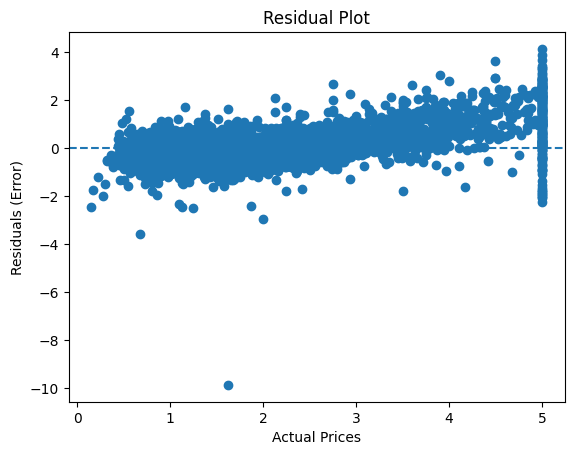

In [2]:
residuals = y_test - predictions

plt.scatter(y_test, residuals)
plt.axhline(y=0, linestyle='--')

plt.xlabel("Actual Prices")
plt.ylabel("Residuals (Error)")
plt.title("Residual Plot")

plt.show()

## Reflection

If the residual plot shows a clear U-shaped pattern instead of random scatter, it indicates that the relationship between the features and the target variable is non-linear. 

This means that the Linear Regression model is not able to capture the underlying pattern in the data, leading to systematic errors. In such cases, the model is underfitting, and a more complex model such as polynomial regression or tree-based methods would be more appropriate.